In [ ]:
import json

documents = json.load(open("lufthansa_data.json", encoding="utf-8"))
print("Loaded:", len(documents), "docs\n")

# Inspect a few raw texts to see what cleaning they need
for d in documents[:5]:
    print(repr(d["text"]))   
    print("---")

Loaded: 202 docs

"Financial reports - Lufthansa Group Investor Relations. Financial reports 1st Interim Report 2026 Lufthansa Group publishes its 1st interim report 2026. Carsten Spohr, Chairman of the Executive Board and Till Streichert, Member of the Executive Board and CFO present the three month figures of 2026 in an Analysts' Conference."
---
'Lufthansa - Annual Reports - CompaniesMarketCap.com. Lufthansa Annual Reports from 2011 to 2025'
---
'Lufthansa Group Posts Record Revenue, Profit Surge. The Lufthansa Group has reported its strongest financial performance in the company’s 100-year history.'
---
"Financial Data - Lufthansa Technik. Lufthansa Technik AG again generated earnings of more than 600 million euros in the 2025 financial year, laying the foundation for further extensive investments in the future. The company's revenue exceeded eight billion euros for the first time, reaching 8.049 billion euros at the end of the..."
---
'Lufthansa reports 2025 operating profit beat,

### Cleaning  
    whitespace normalization and dropping too-short/junk docs ( a doc with 5 characters is noise)
#### I deliberately avoided stopword removal, stemming, and lowercasing, because sentence-transformer embeddings are trained on natural language and rely on case, punctuation, and stopwords for meaning. Heavy cleaning helps BoW/TF-IDF, not embeddings.

In [3]:
import re

def clean_text(text):
    text = re.sub(r"\s+", " ", text)  
    text = re.sub(r"\.{2,}", ".", text)
    text = text.strip()               
    return text

In [4]:
cleaned_docs = []
for d in documents:
    t = clean_text(d["text"])
    if len(t) > 30:          
        d["text"] = t       
        cleaned_docs.append(d)

print("Before cleaning:", len(documents))
print("After cleaning: ", len(cleaned_docs))

Before cleaning: 202
After cleaning:  196


In [5]:
import chromadb
client = chromadb.PersistentClient(path="chroma_db")

In [6]:
ids       = [str(i) for i in range(len(cleaned_docs))]              # unique ID per doc
texts     = [d["text"] for d in cleaned_docs]                       # the text to embed
metadatas = [{"source": d["source"], "url": d["url"]} for d in cleaned_docs]  # evidence

In [7]:
collection = client.get_or_create_collection("lufthansa")

collection.add(
    documents=texts,
    metadatas=metadatas,
    ids=ids,
)

print("Stored:", collection.count(), "documents")

Stored: 196 documents


In [ ]:
results = collection.query(
    query_texts=["What are the biggest risks for Lufthansa?"],
    n_results=3
)

for doc, meta in zip(results["documents"][0], results["metadatas"][0]):
    print(f"[{meta['source']}] {doc[:150]}")
    print(f"    {meta['url']}\n")

[news] Deutsche Lufthansa : Lufthansa CEO sees. | MarketScreener. Lufthansa expects the level of business travel in the medium term to be around 90% or more 
   → https://www.marketscreener.com/quote/stock/LUFTHANSA-436827/news/Deutsche-Lufthansa-Lufthansa-CEO-sees-business-travel-recovering-faster-than-thought-36769814/

[news] Current information | Lufthansa. Get the latest flight information including updates on routes, cancellations due to weather conditions or strikes, re
   → https://www.lufthansa.com/us/en/prepare-for-your-trip/current-travel-information

[company] Downloads - report.lufthansagroup.com. Overall statement by the Executive Board on the expected development of the Lufthansa Group Disclosures in acco
   → https://report.lufthansagroup.com/2024/annual-report/en/downloads/



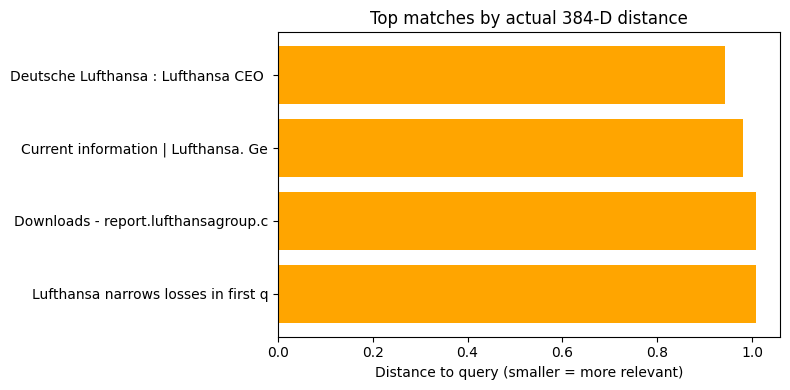

In [15]:
import matplotlib.pyplot as plt

results = collection.query(query_texts=["What are the biggest risks for Lufthansa?"], n_results=5)   # distances returned by default
docs  = [d[:35] for d in results["documents"][0]]
dists = results["distances"][0]

plt.figure(figsize=(8, 4))
plt.barh(docs, dists, color="orange")
plt.xlabel("Distance to query (smaller = more relevant)")
plt.title("Top matches by actual 384-D distance")
plt.gca().invert_yaxis()      # best match on top
plt.tight_layout(); plt.show()


d:\nihal\datacamp\ML practice\ml_env\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


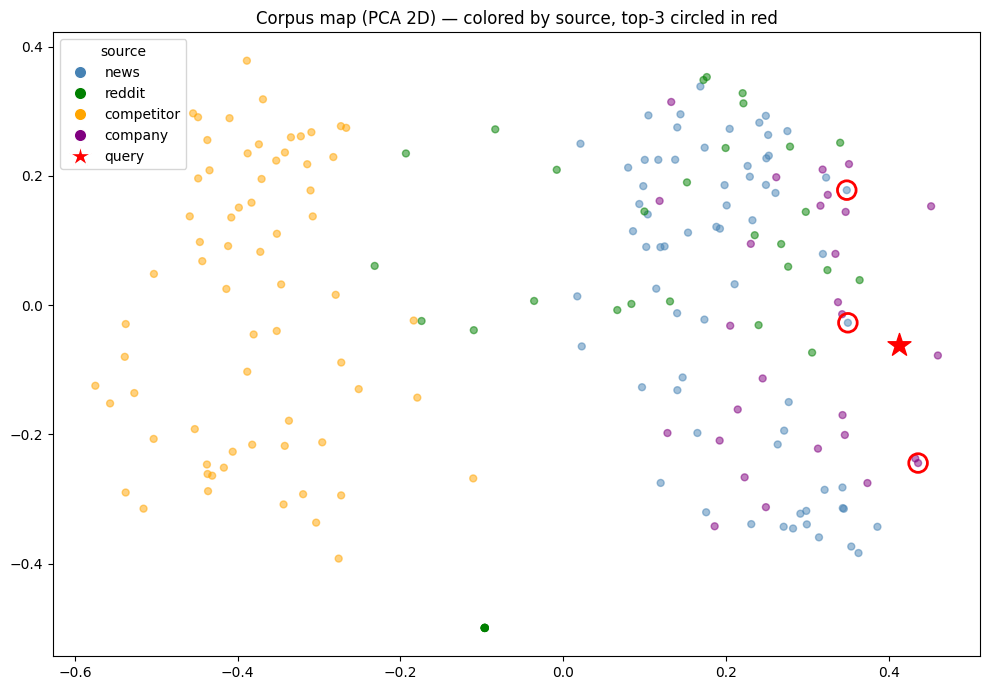

In [14]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np

query = "What are the biggest risks for Lufthansa?"

# 1. embed docs + query
model   = SentenceTransformer("all-MiniLM-L6-v2")
doc_emb = model.encode(texts)
q_emb   = model.encode([query])

# 2. squash 384 -> 2
coords = PCA(n_components=2).fit_transform(np.vstack([doc_emb, q_emb]))
doc_xy, q_xy = coords[:-1], coords[-1]

# 3. get the real top-3 from Chroma (ids = positions)
results = collection.query(query_texts=[query], n_results=3)
top_idx = [int(i) for i in results["ids"][0]]

# 4. color each doc by its source (aligned with texts via cleaned_docs)
cmap = {"news": "steelblue", "reddit": "green", "competitor": "orange", "company": "purple"}
pt_colors = [cmap[d["source"]] for d in cleaned_docs]

# 5. plot
plt.figure(figsize=(10, 7))
plt.scatter(doc_xy[:, 0], doc_xy[:, 1], c=pt_colors, s=25, alpha=0.5)                 # all docs
plt.scatter(doc_xy[top_idx, 0], doc_xy[top_idx, 1], s=180, facecolor="none",          # circle top-3
            edgecolor="red", linewidth=2, zorder=5)
plt.scatter(q_xy[0], q_xy[1], c="red", s=300, marker="*", zorder=6)                   # query

# custom legend (sources + query)
handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=9, label=s)
           for s, c in cmap.items()]
handles.append(Line2D([0], [0], marker="*", color="w", markerfacecolor="red", markersize=16, label="query"))
plt.legend(handles=handles, title="source")
plt.title("Corpus map (PCA 2D) — colored by source, top-3 circled in red")
plt.tight_layout(); plt.show()

In [16]:
%pip install rank_bm25

Note: you may need to restart the kernel to use updated packages.


In [17]:
from rank_bm25 import BM25Okapi

# tokenize each document (lowercase + split into words) — BM25 works on word lists
tokenized_corpus = [doc.lower().split() for doc in texts]

bm25 = BM25Okapi(tokenized_corpus)
print("BM25 index built over", len(tokenized_corpus), "docs")

BM25 index built over 196 docs
